# Week 9 - Introduction to Neural Networks

**Student Name 1, Student Name 2**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with the basics of keras
>* input-output with keras
>* construction of neural network models with keras

This week, we will be exploring the basics of keras and building and fitting our first neural network with keras. For a quick introduction, please see https://keras.io/getting_started/intro_to_keras_for_engineers/

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Simulated Data

In the first part of this workshop, we will work with a simple simulated example to gain some basic understanding of neural networks and keras.

We generate $N=2000$ simulated data points. First we generate the labels assuming that:
$$  y_i \sim \text{Bern}(0.5).$$
Next, we generate the features of dimension $D=2$. The first feature is simulated uniformly in $[-\pi,\pi]$
$$x_{i,1} \sim \text{Uniform}(-\pi,\pi).$$
For the second feature, if $y=0$, then
$$x_{i,2} \sim \text{Norm}(\cos( x_{i,1}),\sigma^2).$$
Otherwise, if $y=1$, then
$$x_{i,2} \sim  \text{Norm}(1+ \cos( x_{i,1}),\sigma^2).$$

In [2]:
# Generate data
keras.utils.set_random_seed(11205)
N = 2000
D = 2
y = np.random.binomial(1, 0.5, N)
X = np.zeros((N, D))
X[:,0] = np.random.uniform(-np.pi, np.pi, N)
X[y == 0,1] = np.cos(X[y == 0,0]) + np.random.normal(0, 0.25, (y == 0).sum())
X[y == 1,1] = 1 + np.cos(X[y == 1,0]) + np.random.normal(0, 0.25, (y == 1).sum())

### 🚩 Exercise 1 (CORE)

Plot the data colored by the class labels. 

**EXTRA.** Derive the true decision boundary and add it to the plot. 

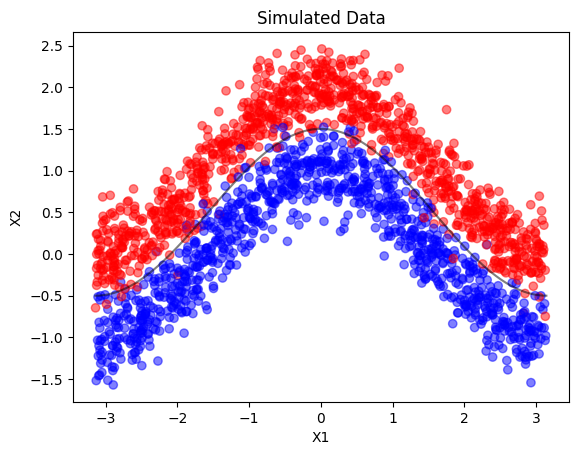

In [3]:
# Plot the data colored by class
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.5)
plt.xlabel('X1')
plt.ylabel('X2')
x1_grid = np.linspace(-np.pi, np.pi, 100)
x2_grid = 1/2+ np.cos(x1_grid)
plt.plot(x1_grid, x2_grid, 'k-', alpha=0.5)
plt.title('Simulated Data')
plt.show()

The true decision boundary is defined as:
\begin{align*}
p(y=1|\mathbf{x}) = 0.5
\end{align*}
Using Bayes rule, we have that:
\begin{align*}
p(y=1|\mathbf{x}) &= \frac{p(\mathbf{x}|y=1)p(y=1)}{p(\mathbf{x}|y=1)p(y=1) + p(\mathbf{x}|y=0)p(y=0)}\\
 &= \frac{\frac{1}{2\pi} \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{1}{2\sigma^2} (x_2 - 1 - \cos(x_1))^2 \right)\frac{1}{2}}{\frac{1}{2\pi} \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{1}{2\sigma^2} (x_2 - 1 - \cos(x_1))^2 \right)\frac{1}{2} + \frac{1}{2\pi} \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{1}{2\sigma^2} (x_2 - \cos(x_1))^2 \right)\frac{1}{2}}.
\end{align*}
Thus, $p(y=1|\mathbf{x}) = 0.5$, when
\begin{align*}
(x_2 - 1 - \cos(x_1))^2 = (x_2 - \cos(x_1))^2,
\end{align*}
or when,
\begin{align*}
x_2 - 1 - \cos(x_1) = -x_2 +\cos(x_1).
\end{align*}
Thus, the decision boundary is:
\begin{align*}
x_2 = \frac{1}{2} + \cos(x_1).
\end{align*}

## Building a baseline logistic regression in keras

Let's start by building a logistic regression model in keras, using the `Functional` model: https://keras.io/guides/functional_api/ 

A `Functional` model provides a way to build a directed graph of `Layers` that connect to each other. `Layers` are the basic building blocks of neural networks in keras:  https://keras.io/api/layers/

To construct a logistic regression model, we only need two layers: 
- an input layer, which we construct using an `Input` layer: https://keras.io/api/layers/core_layers/input/ 
- an output layer, which we construct using a `Dense` layer: https://keras.io/api/layers/core_layers/dense/

In [4]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
logit_layer = keras.layers.Dense(1, activation='sigmoid')

Then, we combine the layers and create our model which connects the input and output. 

In [5]:
output = logit_layer(input_layer)
model_lr = keras.models.Model(input_layer, output)
model_lr.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Print the number of layers in the model
print(len(model_lr.layers)) 

2


Alternatively, we can build the model using the `Sequential` model, see https://keras.io/api/models/sequential/ and https://keras.io/guides/sequential_model/. A `Sequential` model is esssentially a plain stack of `Layers` where each layer has exactly one input tensor and one output tensor, while a `Functional` model allows more general constructions (i.e. a graph of layers). 

In [7]:
model_lr2 = keras.Sequential(
    [
        keras.Input(shape=(D,)),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)
model_lr2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Now, we are ready to compile the model: https://keras.io/api/models/model_training_apis/

When compiling, we need to specify:
- a loss function: https://keras.io/api/losses/
- an optimizer: https://keras.io/api/optimizers/
- (optionally) metrics: https://keras.io/api/metrics/

In [8]:
model_lr.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

### Training the model

Now, we are ready to to fit the model! We need to specifiy: 
- the number of `epochs` (which is the number of times that we cycle through the whole training data during gradient descent), 

and optionally various other parameters, such as 

- `shuffle` (e.g. `shuffle=True`), which specifies whether to shuffle the training data before each epoch.
- `validation_split` which is a float between 0 and 1, determining the fraction of the training data to be used as validation data. The model will set apart this fraction of the training data, will not train on it, and will evaluate the loss and any model metrics on this data at the end of each epoch. This is useful for **early stopping**, i.e. determining if training should be stopped early to prevent overfitting.
- `batch_size`: Integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32. 
For more details, see: https://keras.io/api/models/model_training_apis/

**Caution:** the data is not shuffled before splitting the data into a validation set. If the data are ordered in particular way when stored, then the training and validation sets can potentially characterize different populations. Thus, it is recommend to first shuffle the order of your data before fitting.  

In [9]:
# If you need to shuffle the data before fitting uncomment the following lines
# from sklearn.utils import shuffle
# X, y = shuffle(X, y, random_state=11205)

In [10]:
model_lr.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5272 - auc: 0.5536 - loss: 0.8589 - val_accuracy: 0.5250 - val_auc: 0.5678 - val_loss: 0.8517
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5344 - auc: 0.5721 - loss: 0.8220 - val_accuracy: 0.5350 - val_auc: 0.5887 - val_loss: 0.8177
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5389 - auc: 0.5955 - loss: 0.7877 - val_accuracy: 0.5300 - val_auc: 0.6126 - val_loss: 0.7864
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5411 - auc: 0.6241 - loss: 0.7562 - val_accuracy: 0.5300 - val_auc: 0.6355 - val_loss: 0.7576
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5472 - auc: 0.6561 - loss: 0.7275 - val_accuracy: 0.5250 - val_auc: 0.6572 - val_loss: 0.7315
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5483 - auc: 0.6863 - loss: 0.7014 - val_accuracy: 0.5150 - val_auc: 0.6845 - val_loss: 0.7080
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - 

Let's plot the metrics as a function of the number of epochs.

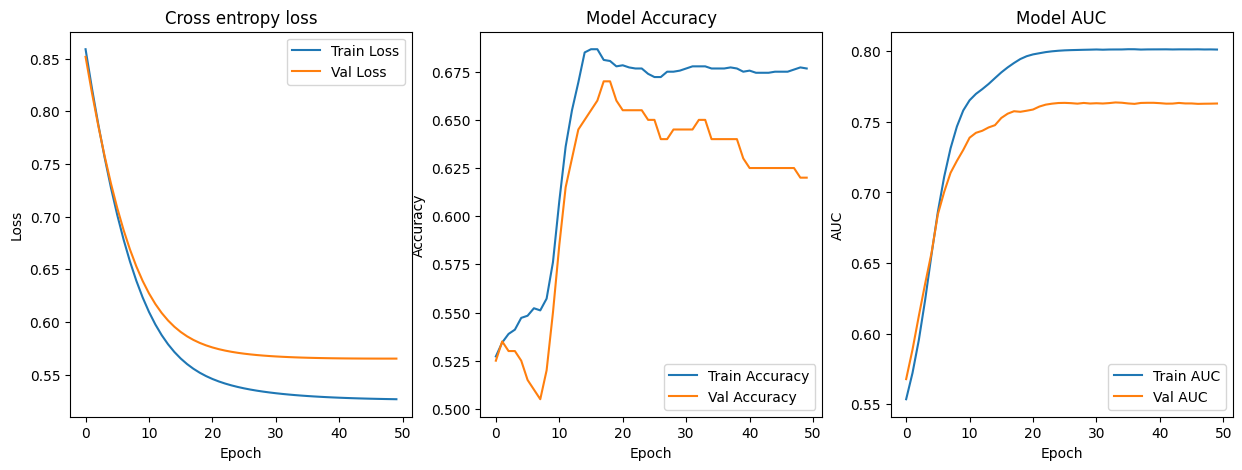

In [11]:
# Plot the training history
history = model_lr.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

If you notice that the validation loss (and metrics) is still decreasing (increasing) as a function of epochs, this suggests that you may need to train the model longer.

If you notice that the validation loss (and metrics) starts to increase (decrease) as a function of epochs, this suggests that the model is starting to overfit. Based on this, we can determine the number of epochs to use based on the U-shape of the validation loss (this is known as early stopping, for more info see: https://keras.io/api/callbacks/early_stopping/). 

### Testing the model

Now, we can use `.predict()` to make predictions. Let's predict at a grid of test points and draw a heatmap of the predicted probabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step


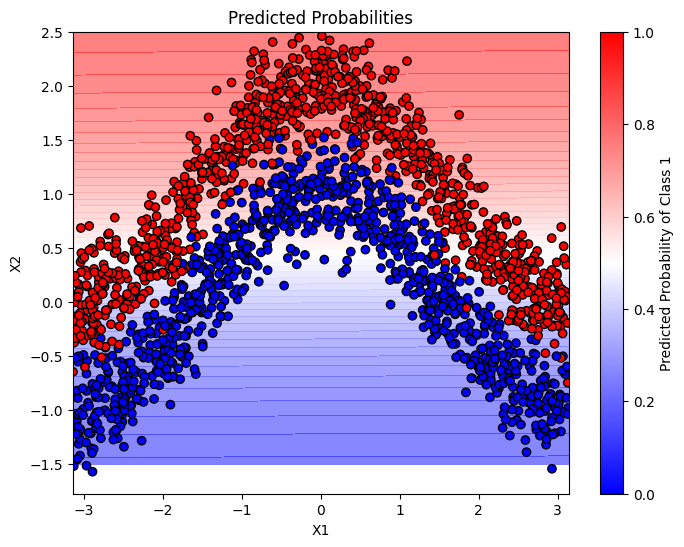

In [12]:
# Create a grid of test points
X_grid1, X_grid2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-1.5, 2.5, 100))
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

# Predict probabilities 
y_pred_prob_lr = model_lr.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_lr.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

### 🚩 Exercise 2 (CORE)

- Generate 1000 test data points from the same data generating process used to generated the training data.
- Compute the `classification_report` and `confusion_matrix`
- Is the result what you expect, and why?

In [13]:
# Generate test data
N_test = 2000
y_test = np.random.binomial(1, 0.5, N_test)
X_test = np.zeros((N_test, 2))
X_test[:,0] = np.random.uniform(-np.pi, np.pi, N_test)
X_test[y_test == 0,1] = np.cos(X_test[y_test == 0,0]) + np.random.normal(0, 0.2, (y_test == 0).sum())
X_test[y_test == 1,1] = 1 + np.cos(X_test[y_test == 1,0]) + np.random.normal(0, 0.2, (y_test == 1).sum())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step
              precision    recall  f1-score   support

           0       0.71      0.66      0.68      1026
           1       0.67      0.72      0.69       974

    accuracy                           0.69      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.69      0.69      0.69      2000



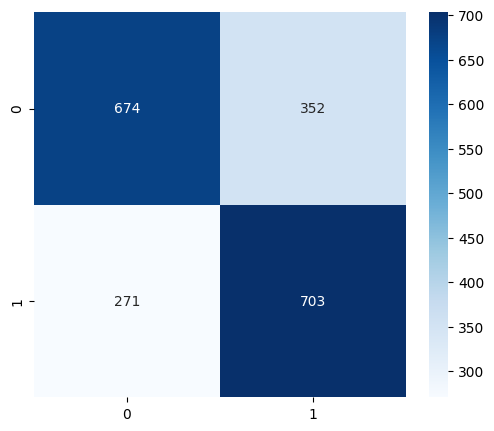

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
y_test_pred_prob_lr = model_lr.predict(X_test)
y_test_pred_lr = (y_test_pred_prob_lr > 0.5).astype(int)
print(classification_report(y_test, y_test_pred_lr))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.show()

The preditcion is poor. This is expected as logistic regression assumes a linear decision boundary, but the true decision boundary is nonlinear.

### Adding a hidden layer

Now, let's add a hidden layer, with 2 neurons.

In [15]:
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(2, activation='relu')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden2 = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### 🚩 Exercise 3 (CORE)

Compile the model, train and plot the metrics as a function of epochs. 

Continue to train the model for more epochs as needed. Note: rerun the fit line will continue to train the model from where it left off.

In [16]:
model_hidden2.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

In [29]:
model_hidden2.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9650 - auc: 0.9942 - loss: 0.1349 - val_accuracy: 0.9450 - val_auc: 0.9844 - val_loss: 0.1704
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9942 - loss: 0.1343 - val_accuracy: 0.9450 - val_auc: 0.9845 - val_loss: 0.1700
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9941 - loss: 0.1338 - val_accuracy: 0.9450 - val_auc: 0.9845 - val_loss: 0.1695
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9942 - loss: 0.1332 - val_accuracy: 0.9450 - val_auc: 0.9846 - val_loss: 0.1691
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9942 - loss: 0.1327 - val_accuracy: 0.9450 - val_auc: 0.9847 - val_loss: 0.1687
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9942 - loss: 0.1322 - val_accuracy: 0.9450 - val_auc: 0.9846 - val_loss: 0.1683
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

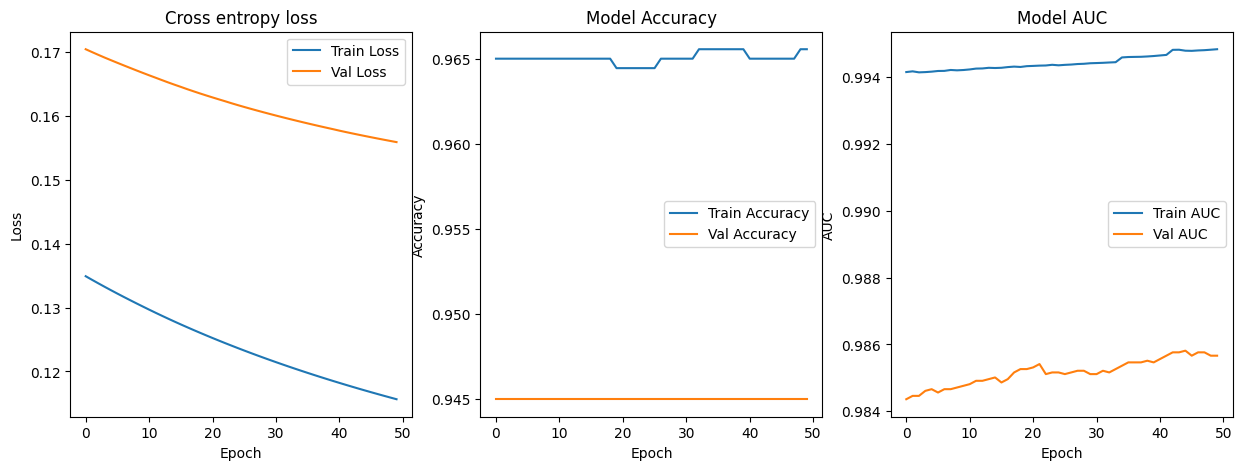

In [30]:
# Plot the training history
history = model_hidden2.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

Note that we ran that fit cell multiple times, until the training validation loss and metrics seemed to stabilize.

### 🚩 Exercise 4 (CORE)

Draw a heatmap of the predicted probabilities. How does the model perform now?

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step


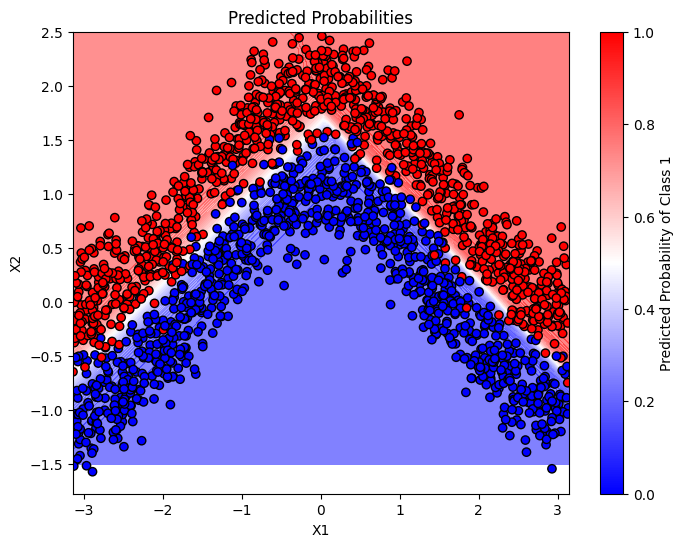

In [31]:
# Predict probabilities 
y_pred_prob = model_hidden2.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

Adding the hidden layer with only two neurons increases the model flexibly and it is now able to recover the nonlinear decision boundary.

### Visualizing the output of each neuron

By visualizing the output of each neuron, we can gain an understanding of the features extracted. 

In the code below, we create a keras model for the mapping of the inputs to the hidden layer and pass through the data. By plotting the output of the hidden layer, we observe that:
- the first hidden feature captures the separation of the two classes when $x_1<0$ and 
- the second hidden feature captures the separation of the two classes when $x_1>0$.

In [32]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden2.input, outputs=model_hidden2.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

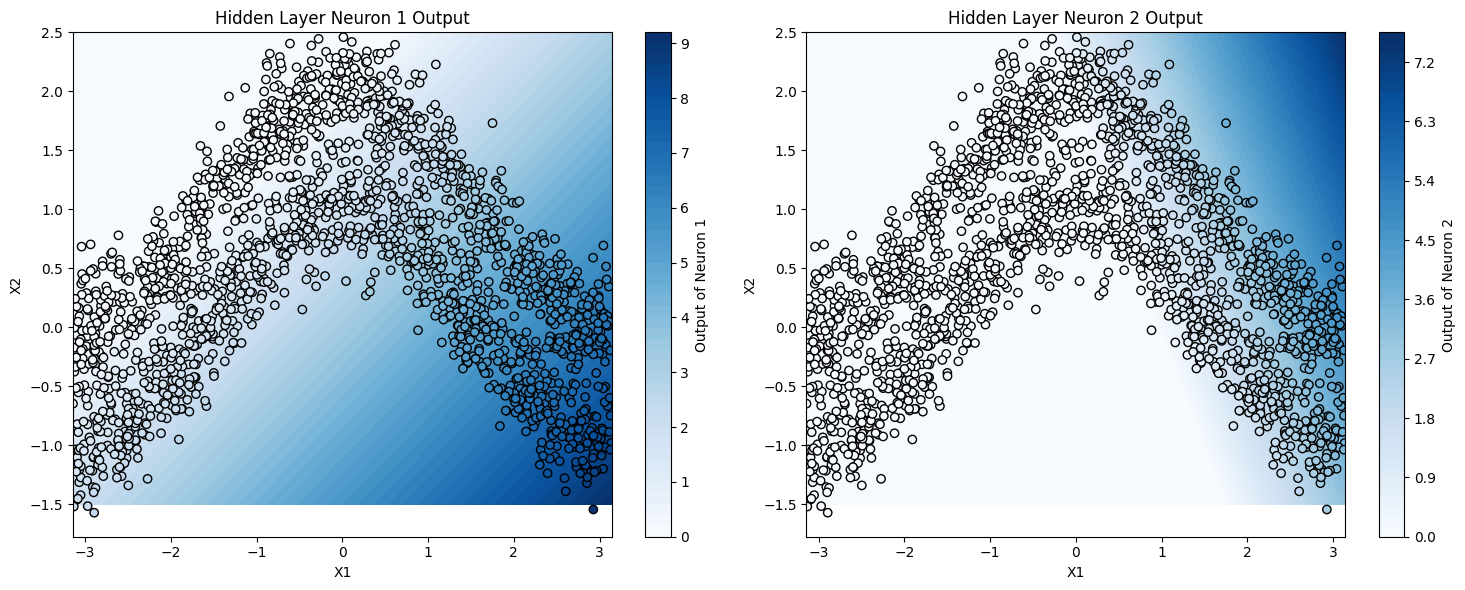

In [33]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(2):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k',vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout() 
plt.show()

We can also print out the values of the weights and bias for each layer:

In [34]:
print('Hidden layer bias:', model_hidden2.layers[1].bias.numpy())
print('Hidden layer weights:', model_hidden2.layers[1].kernel.numpy())
print('Output layer bias:', model_hidden2.layers[2].bias.numpy())
print('Output layer weights:', model_hidden2.layers[2].kernel.numpy())

Hidden layer bias: [ 3.2926228 -1.9977282]
Hidden layer weights: [[ 1.1378622  2.1483486]
 [-1.5281255  1.1175686]]
Output layer bias: [2.735736]
Output layer weights: [[-3.6818523]
 [ 6.6227593]]


### Increasing the width of the network

### 🚩 Exercise 5 (CORE)

Now, try increasing the number of hidden units to 5.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and what features appear to be extracted by each hidden unit. Which model would you choose and why?

In [35]:
# Define the model with 5 hidden neurons
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(5, activation='relu')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden5 = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden5.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Compile the model

model_hidden5.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9672 - auc: 0.9965 - loss: 0.1033 - val_accuracy: 0.9500 - val_auc: 0.9908 - val_loss: 0.1319
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9667 - auc: 0.9965 - loss: 0.1027 - val_accuracy: 0.9500 - val_auc: 0.9909 - val_loss: 0.1315
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9667 - auc: 0.9965 - loss: 0.1022 - val_accuracy: 0.9500 - val_auc: 0.9910 - val_loss: 0.1310
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9667 - auc: 0.9965 - loss: 0.1016 - val_accuracy: 0.9500 - val_auc: 0.9911 - val_loss: 0.1306
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9672 - auc: 0.9965 - loss: 0.1011 - val_accuracy: 0.9500 - val_auc: 0.9910 - val_loss: 0.1302
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9672 - auc: 0.9965 - loss: 0.1006 - val_accuracy: 0.9500 - val_auc: 0.9911 - val_loss: 0.1298
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

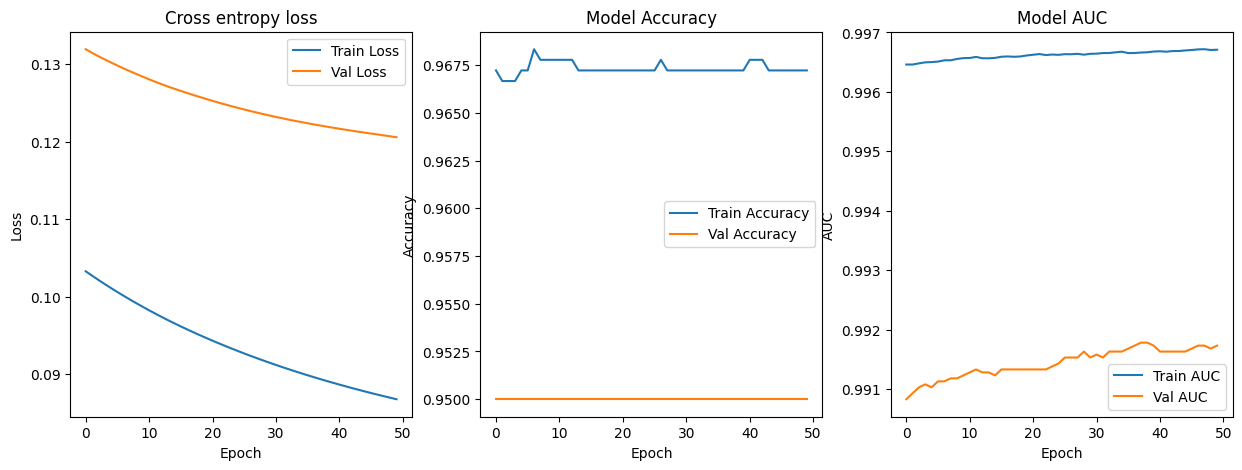

In [39]:
# Fit the model - note we have run the cell multiple times to get a good fit, you may need to do the same
model_hidden5.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

# Plot the training history
history = model_hidden5.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

The validation loss is still slightly decreasing, but the accuracy and AUC seem fairly stable.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step


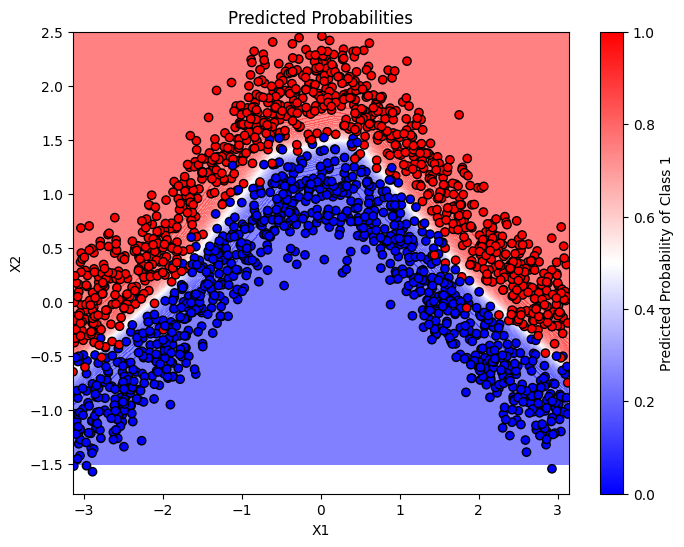

In [40]:
# Predict probabilities 
y_pred_prob = model_hidden5.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

In [41]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden5.input, outputs=model_hidden5.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

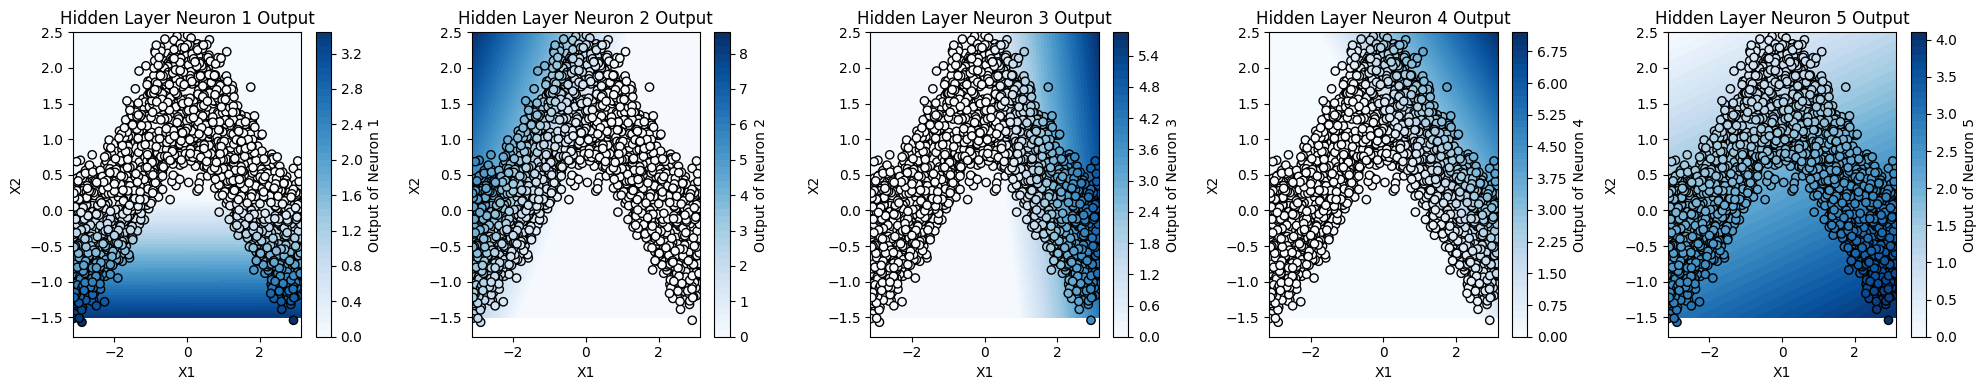

In [42]:

# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1,5, figsize=(20, 4))
for i in range(5):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k', vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout()    
plt.show()

The predictions are similar to the case with only two neurons, but the decision boundary is slightly smoother with 5 hidden units.

The hidden units appear to capture the features:
- hidden unit 1: captures when $x_2<0.2$
- hidden unit 2: mostly separates the classes when $x_1<0$ (similar to hidden unit 1 in the previous model)
- hidden unit 3: represents large values of $x_1$ (and to a lesser extent large values of $x_2$)
- hidden unit 4: separates the classes when $x_1>0$ (similar to hidden unit 2 in the previous model)
- hidden unit 5: is a linear function of $x_1$ and $x_2$

We have increased the number of parameters from 9 to 21, but the overall improvement is small. Thus, we may prefer either model depending on the performance/complexity tradeoff. 

In [43]:
print('Hidden layer bias:', model_hidden5.layers[1].bias.numpy())
print('Hidden layer weights:', model_hidden5.layers[1].kernel.numpy())
print('Output layer bias:', model_hidden5.layers[2].bias.numpy())
print('Output layer weights:', model_hidden5.layers[2].kernel.numpy())

Hidden layer bias: [ 0.38739038 -1.2848638  -1.0646516  -1.3149164   2.4075286 ]
Hidden layer weights: [[ 0.00312583 -1.9390118   1.8538573   1.4343901   0.17973267]
 [-2.0276241   1.488509    0.43044132  1.5782404  -0.74376047]]
Output layer bias: [-1.6905743]
Output layer weights: [[-1.5429521]
 [ 3.0725393]
 [ 1.8707764]
 [ 3.226352 ]
 [-3.259853 ]]


### Increasing the depth of the network

### 🚩 Exercise 6 (CORE)

Now, consider a model with two layers: 5 hidden units in the first layer and 2 hidden units in the second layer.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit (in both layers) over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted by the second layer compared to the first. Which model would you choose and why?

In [44]:
# Define the model with 5 hidden neurons
input_layer = keras.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(5, activation='relu')(input_layer)
hidden_layer2 = keras.layers.Dense(2, activation='relu')(hidden_layer1)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer2)
model_hidden_2lay = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden_2lay.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Compile the model

model_hidden_2lay.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9678 - auc: 0.9962 - loss: 0.1520 - val_accuracy: 0.9450 - val_auc: 0.9914 - val_loss: 0.1746
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9678 - auc: 0.9962 - loss: 0.1487 - val_accuracy: 0.9500 - val_auc: 0.9913 - val_loss: 0.1723
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9678 - auc: 0.9961 - loss: 0.1456 - val_accuracy: 0.9500 - val_auc: 0.9914 - val_loss: 0.1700
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9678 - auc: 0.9960 - loss: 0.1427 - val_accuracy: 0.9500 - val_auc: 0.9915 - val_loss: 0.1677
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9683 - auc: 0.9960 - loss: 0.1400 - val_accuracy: 0.9500 - val_auc: 0.9916 - val_loss: 0.1656
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9689 - auc: 0.9962 - loss: 0.1374 - val_accuracy: 0.9500 - val_auc: 0.9915 - val_loss: 0.1634
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

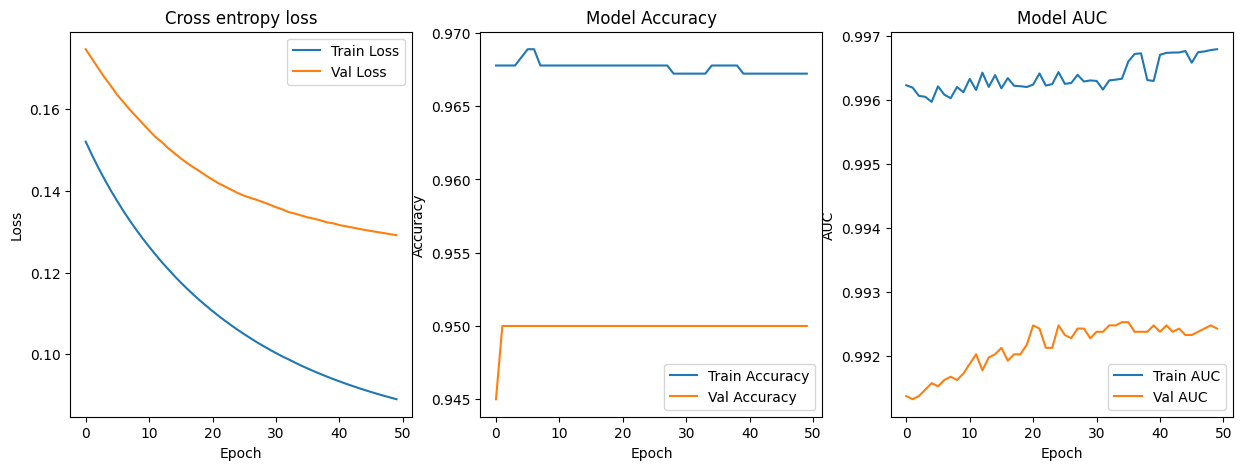

In [47]:
# Fit the model - note we have run the cell multiple times to get a good fit, you may need to do the same
model_hidden_2lay.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

# Plot the training history
history = model_hidden_2lay.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step


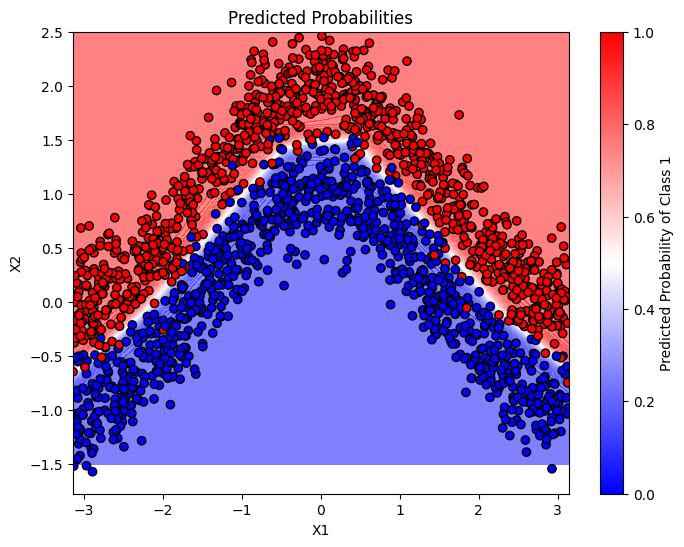

In [48]:
# Predict probabilities 
y_pred_prob = model_hidden_2lay.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

In [49]:
# Extract the output of the hidden layer
hidden_layer1_model = keras.Model(inputs=model_hidden_2lay.input, outputs=model_hidden_2lay.layers[1].output)
hidden_layer2_model = keras.Model(inputs=model_hidden_2lay.input, outputs=model_hidden_2lay.layers[2].output)

# Hidden output for the observed data
z1 =hidden_layer1_model(X)
# Convert to numpy array
z1 = z1.numpy()
z2 =hidden_layer2_model(X)
# Convert to numpy array
z2 = z2.numpy()

# Hidden output for the test points
z1_grid =hidden_layer1_model(X_grid)
# Convert to numpy array
z1_grid = z1_grid.numpy()
z2_grid =hidden_layer2_model(X_grid)
# Convert to numpy array
z2_grid = z2_grid.numpy()

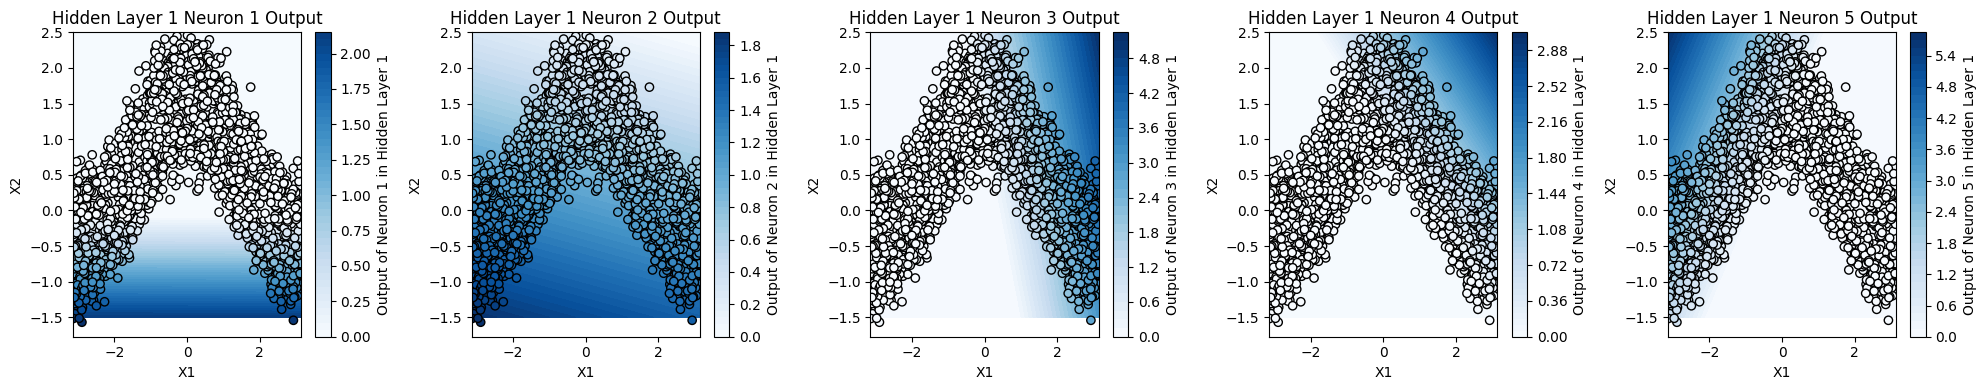

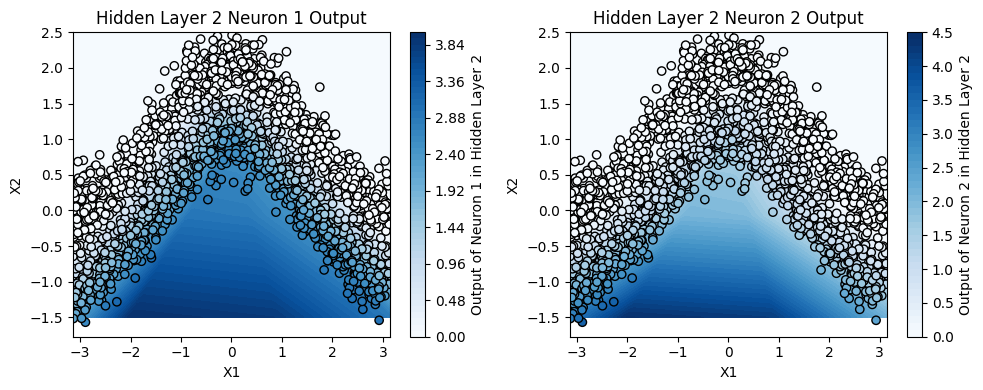

In [50]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1,5, figsize=(20, 4))
for i in range(5):
    vmin= min(z1[:,i].min(), z1_grid[:,i].min())   
    vmax= max(z1[:,i].max(), z1_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z1_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z1[:,i], cmap='Blues', edgecolor='k', vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer 1 Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1} in Hidden Layer 1')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2, figsize=(10, 4))
for i in range(2):
    vmin= min(z2[:,i].min(), z2_grid[:,i].min())   
    vmax= max(z2[:,i].max(), z2_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z2_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z2[:,i], cmap='Blues', edgecolor='k', vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer 2 Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1} in Hidden Layer 2')
fig.tight_layout()
plt.show()

There is very little difference in the predicted probabilities. The output of the hidden units at the second layer now has a more flexible shape. But overall, we observe some redundances (the outputs of the neurons at the second layer are very similar and similar to final output), suggesting that the model may be overparameterized and this additional layer is not needed. Given the increased number of parameters (30) and only modest to no improvement in predictive performance, we may prefer the simpler model with only one hidden layer. 

### Changing the activation function

### 🚩 Exercise 7 (EXTRA)

Next, let's explore changing the activation function. 

- Define and compile with your choice of width and depth (number of layers and number of hidden units within each layer), but consider a different activation function for the hidden layer, namely `tanh`.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted when using the `tanh` activation function instead of the `relu` activation.

In [51]:
# Define the model with 5 hidden neurons
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(2, activation='tanh')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden_tanh = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden_tanh.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Compile the model

model_hidden_tanh.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9644 - auc: 0.9936 - loss: 0.1833 - val_accuracy: 0.9400 - val_auc: 0.9845 - val_loss: 0.2123
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9644 - auc: 0.9938 - loss: 0.1811 - val_accuracy: 0.9400 - val_auc: 0.9848 - val_loss: 0.2103
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9650 - auc: 0.9938 - loss: 0.1791 - val_accuracy: 0.9400 - val_auc: 0.9849 - val_loss: 0.2083
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9656 - auc: 0.9939 - loss: 0.1771 - val_accuracy: 0.9450 - val_auc: 0.9854 - val_loss: 0.2063
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9661 - auc: 0.9940 - loss: 0.1751 - val_accuracy: 0.9450 - val_auc: 0.9858 - val_loss: 0.2044
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9667 - auc: 0.9941 - loss: 0.1732 - val_accuracy: 0.9450 - val_auc: 0.9857 - val_loss: 0.2025
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

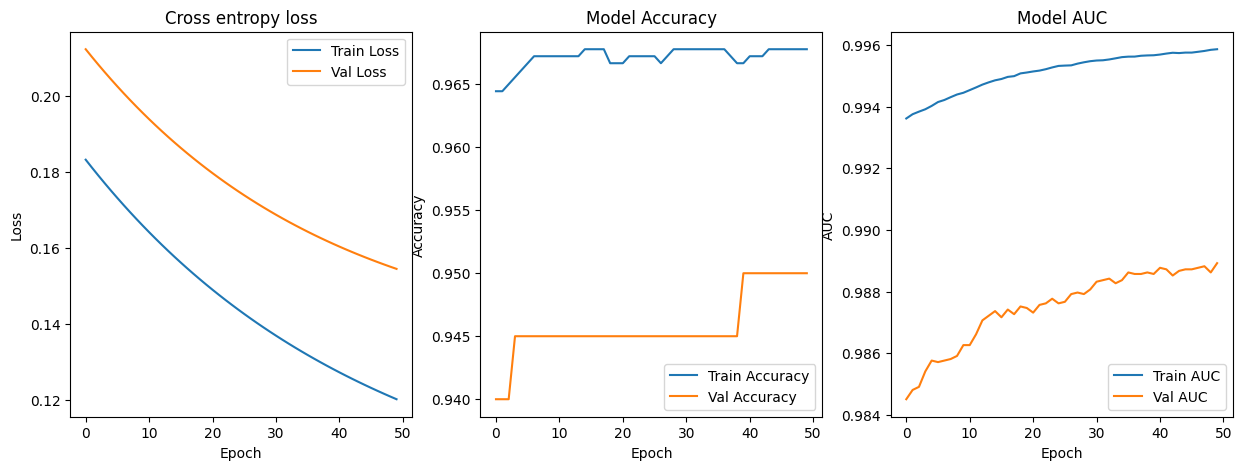

In [55]:
# Fit the model - note we have run the cell multiple times to get a good fit, you may need to do the same
model_hidden_tanh.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

# Plot the training history
history = model_hidden_tanh.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step


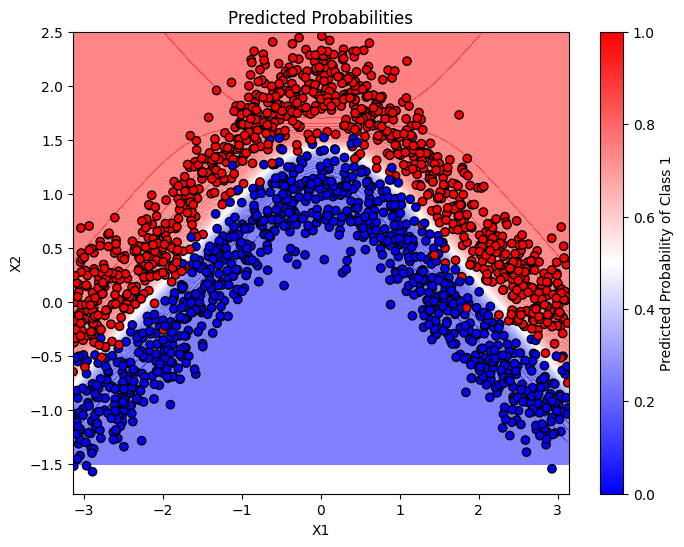

In [56]:
# Predict probabilities 
y_pred_prob = model_hidden_tanh.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

In [57]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden_tanh.input, outputs=model_hidden_tanh.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

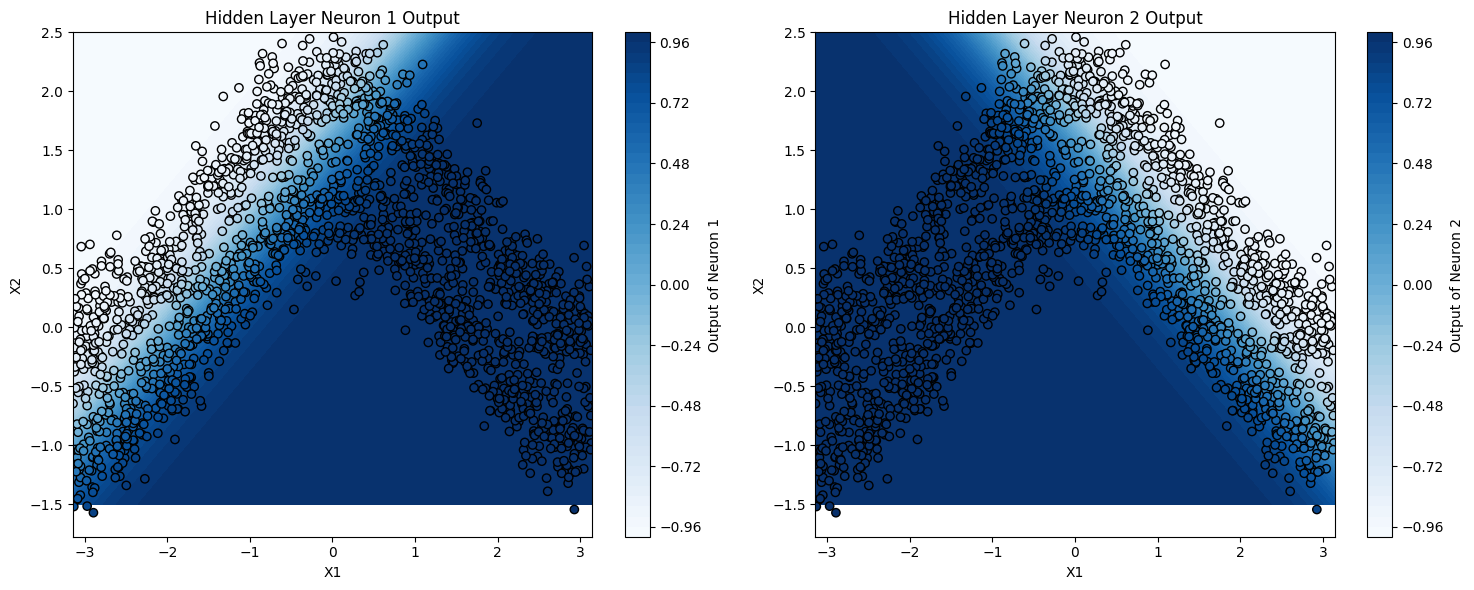

In [58]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(2):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k',vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout() 
plt.show()

The predictive performance is very similar to the case with the ReLU activation function. The main difference lies in the features extracted, which before had the form of the of ReLU (halfplane). Instead, they now mostly take values -1 and 1. Again, the two hidden units correspond to separating the classes when $x_1<0$ (hidden unit 1) and when when $x_1>0$ (hidden unit 2). 

# Part 2: MNIST Data

### Loading, exploring, and preparing the data

For the second part, we are going to use the MNIST dataset, partly because you are already familiar with it, and partly because it comes with tensorflow, the most widely used library for neural networks in python.

Let's start by load the MNIST data using `keras.datasets.mnist.load_data()`

In [59]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)



Let's display the six images in the training set.

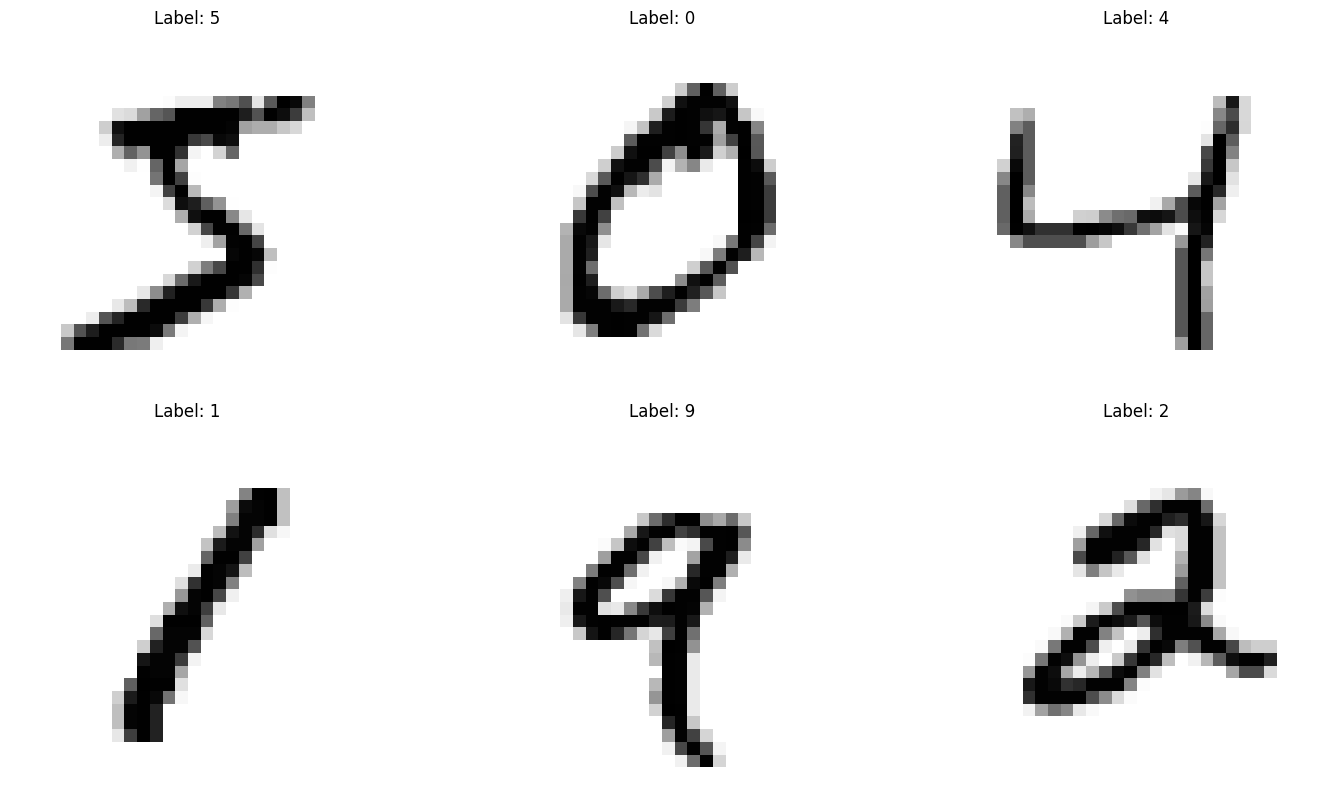

In [60]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()
for i in range(6):
    ax[i].imshow(X_train[i], cmap="gray_r")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis('off')
fig.tight_layout()
plt.show()

Next, we divide the features by 255 (the maximum value of the pixels), so that all pixel values in the training and testing data are between 0 and 1. 

In the workshop, we will be working only with fully connected feed-forward networks (that don't exploit the spatial structure of the images like convolutional neural networks). As such, we also flatten all images to vectors.

In [61]:
# Rescale the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape the data 
X_train = X_train.reshape((-1, 28 * 28))
X_test = X_test.reshape((-1, 28 * 28))

Lastly, we use convert the labels using a `LabelEncoder`.

In [62]:
# Converting the labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 🚩 Exercise 8 (CORE)

As a baseline model, create a pipeline (called `baseline`) that
- first uses PCA to reduce the dimension to 100
- then uses logistic regression with no penalty

Fit the pipeline to the data. Plot the confusion matrix and print the classification report. How many parameters does the logistic regression model have?

In [63]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Pipeline that includes PCA for dimensionality reduction followed by logistic regression
baseline = make_pipeline(
    PCA(n_components=100),
    LogisticRegression(penalty=None)
)

baseline.fit(X_train, y_train)

,steps,"[('pca', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,100
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


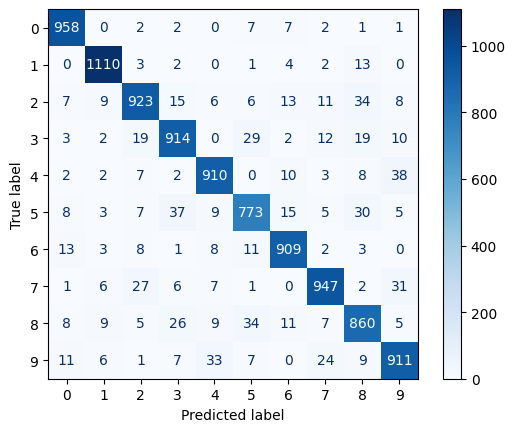

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.92      0.89      0.91      1032
           3       0.90      0.90      0.90      1010
           4       0.93      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [64]:
# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss

ConfusionMatrixDisplay.from_estimator(baseline, X_test, y_test, cmap='Blues')
plt.show()

y_test_pred = baseline.predict(X_test)
print(classification_report(y_test, y_test_pred))

In [65]:
print(baseline[-1].coef_.shape)
print(baseline[-1].intercept_.shape)

(10, 100)
(10,)


The total number of parameters for the logistic regression model is 10*100+10=1010.

Let's plot some of the images that were both correctly and incorrectly classified, along with the corresponding probabilities. 

Note: if you have called your model something other than `baseline`, please change the name in the code below.

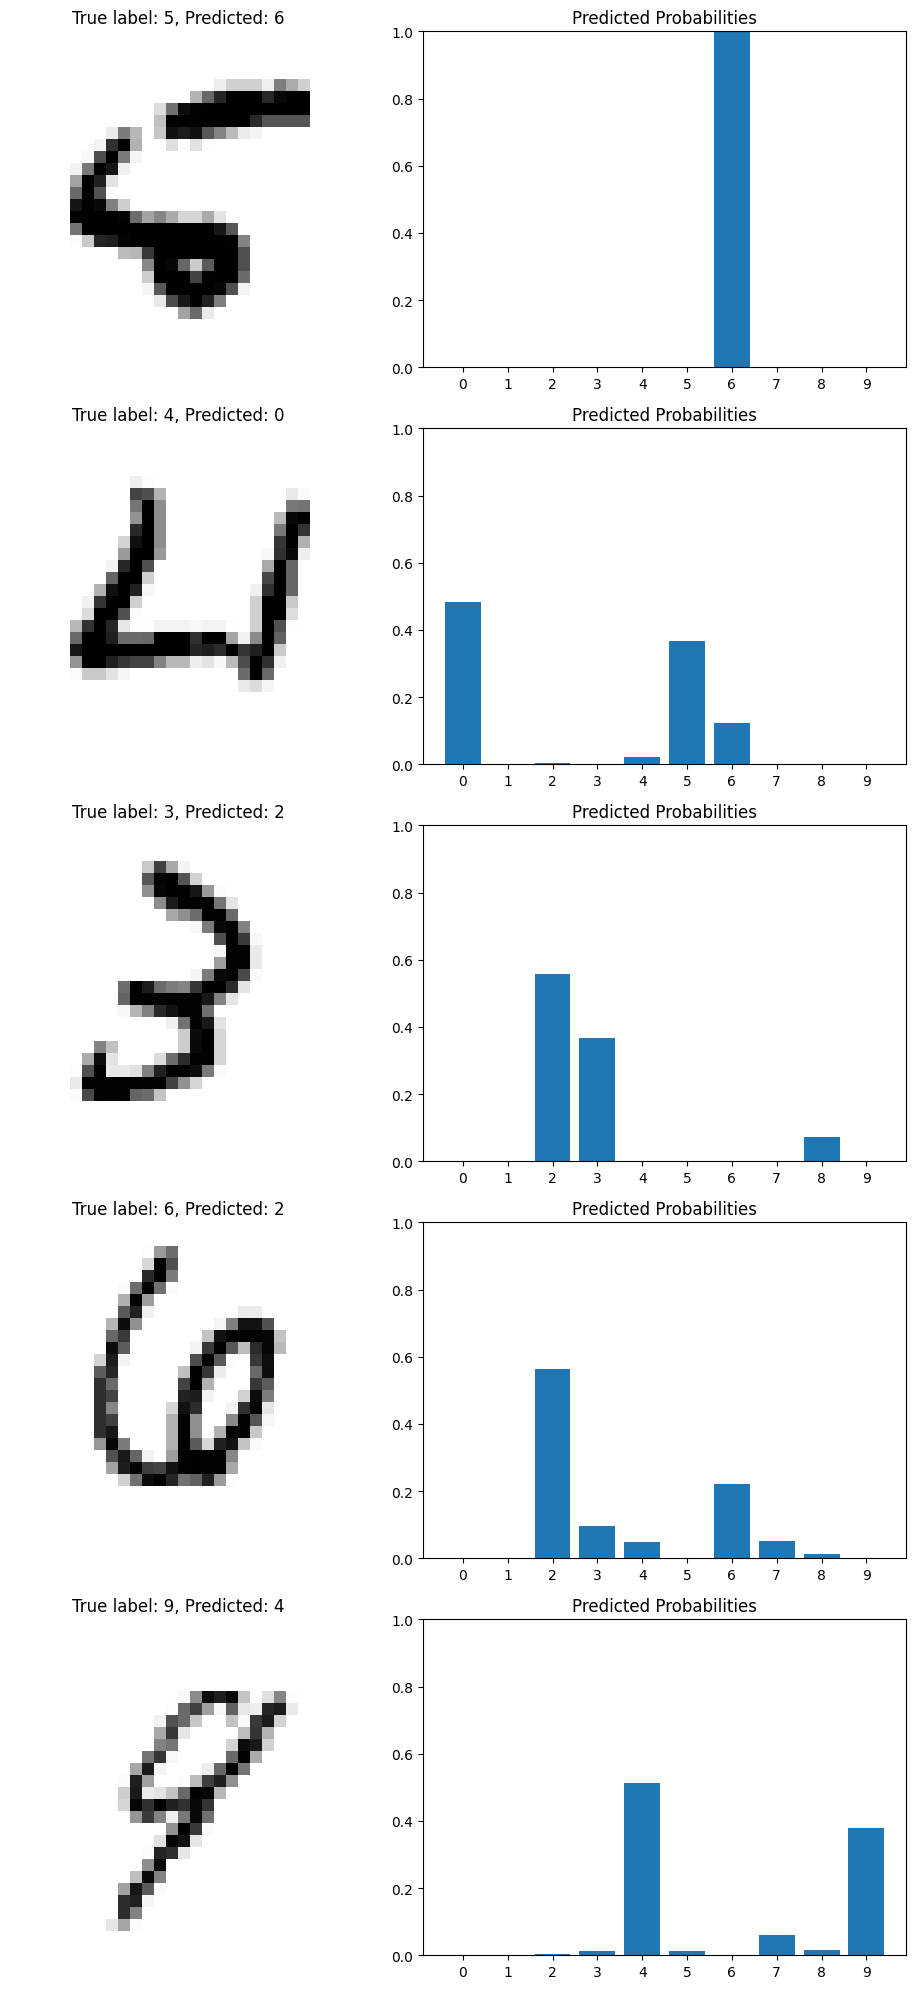

In [66]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

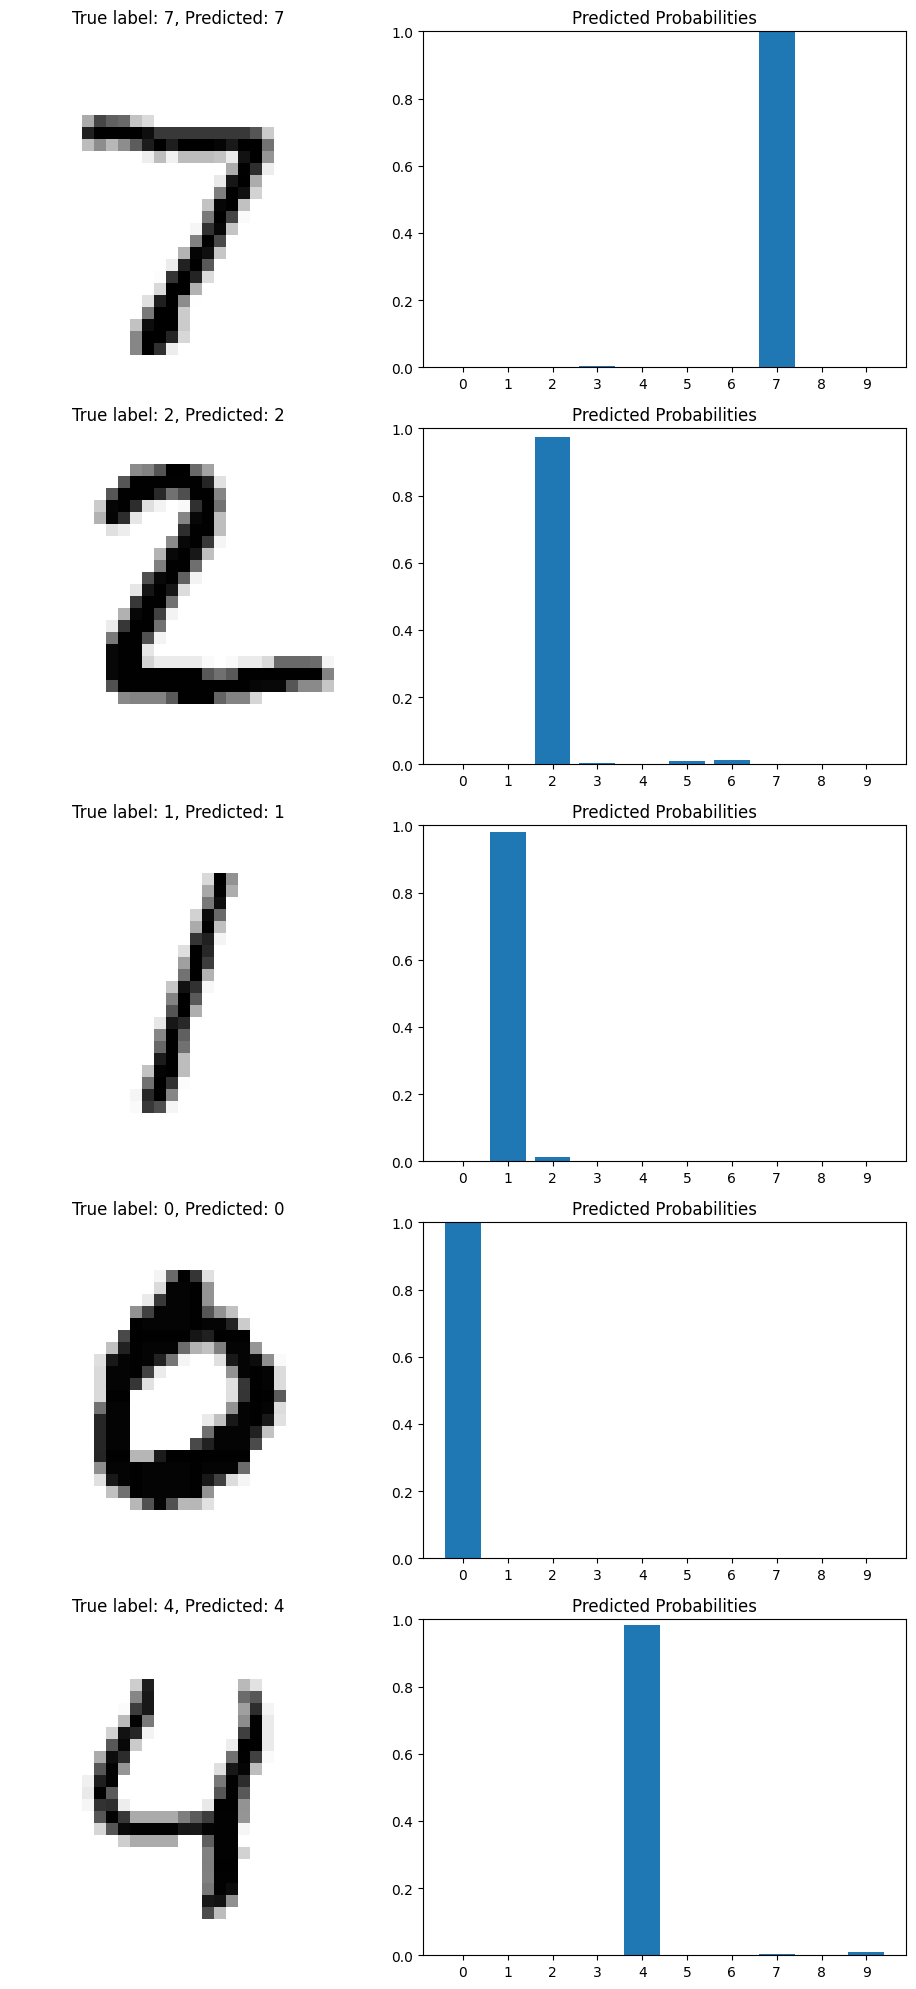

In [67]:
# For the first 5 correctly classified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

It can be concerning when we have high probability/confidence for incorrectly classified images. This is quantified across all data points by the cross entropy loss, which for a single data points computes:

$$ L(y, p) = \sum_{c=1}^C y_c\log(p_c).$$

Notice that if the probability of the true class is close to 1, than the loss is zero, but if it is close to zero that the loss is high. 

We can report the cross entropy loss, averaged across all data points. 

In addition, through histogram showing the distribution of the probability of that $y$ is equal to the true test label, we can gain a more detailed understanding. We see that for the correctly classified images, over 4,000 images are correctly classified with a high probability. On the other hand, there are over 100 images that are misclassified with a high probability. 

Cross entropy loss: 0.2803954565535932


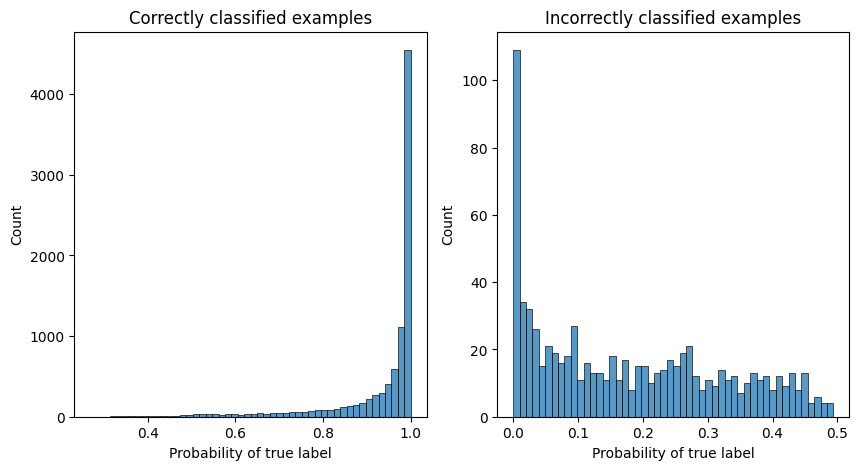

In [68]:
y_test_pred_prob = baseline.predict_proba(X_test)
print('Cross entropy loss:', log_loss(y_test, y_test_pred_prob, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_prob[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

### 🚩 Exercise 9 (CORE)

Next, let's fit a fully-connected feed forwared neural network. Note that we need to one-hot encoding the output labels for use in keras in the multiclass setting.

- Define and compile a model with one hidden layer of 128 neurons and ReLU activation. For the final layer, use a softmax with 10 units to obtain the probabilities for each class. Here use the categorical cross entropy loss. 
- Fit the model and train for 10 epochs with a batch size of 128 and a 10% validation split, and plot the loss and accuracy for the training and validation sets as a function of epochs.
- Plot the confusion matrix and print the classification report on the test data.
- Visualize some the test images, along with their probabilities for both correctly and incorrectly classified images.
- Print the cross entropy loss on the test data, and visualize the distribution of the probability of the true labels for correctly and incorrectly classified test points.

In [69]:
# First create a one-hot encoding of the labels for use in Keras
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
# Print the first few rows before and after one-hot encoding
print("Original labels:", y_train[:5])
print("One-hot encoded labels:\n", y_train_cat[:5])

Original labels: [5 0 4 1 9]
One-hot encoded labels:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [70]:
# Define the model
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# Compile the model
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy'],
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8951 - loss: 0.3798 - val_accuracy: 0.9540 - val_loss: 0.1740
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9486 - loss: 0.1802 - val_accuracy: 0.9637 - val_loss: 0.1299
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9629 - loss: 0.1293 - val_accuracy: 0.9672 - val_loss: 0.1101
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9716 - loss: 0.1001 - val_accuracy: 0.9702 - val_loss: 0.0983
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0811 - val_accuracy: 0.9717 - val_loss: 0.0914
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0672 - val_accuracy: 0.9742 - val_loss: 0.0865
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - loss: 0.0567 - val_accuracy: 0.9750 - val_loss: 0.0832
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9873 - loss: 0.0481 - val_accuracy: 0.

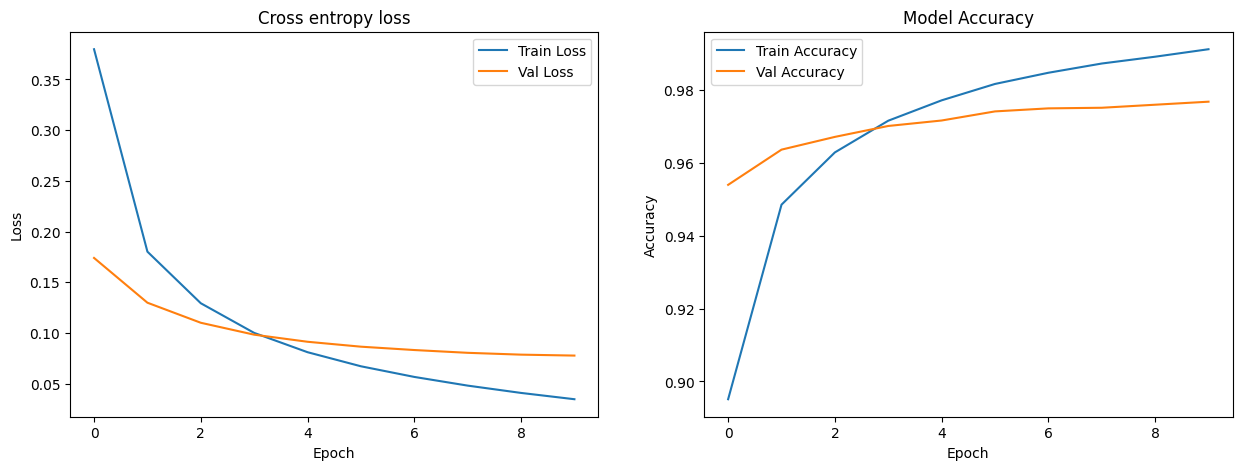

In [71]:
# Fit the model
model.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.1)

# Plot the training history
history = model.history.history
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step


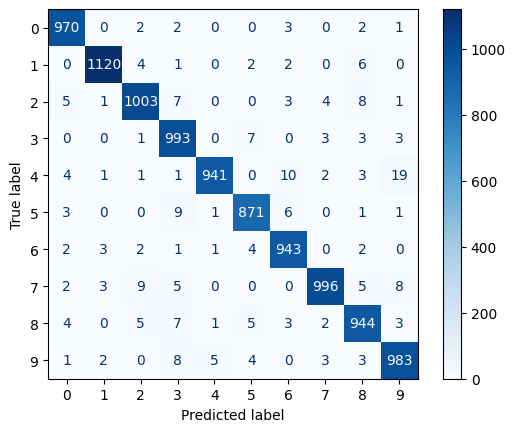

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.98      0.98      0.98       892
           6       0.97      0.98      0.98       958
           7       0.99      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [72]:
# Display the confusion matrix
y_test_pred_nn = model.predict(X_test)
y_test_pred_nn_labels = np.argmax(y_test_pred_nn, axis=1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_nn_labels, cmap='Blues')
plt.show()
print(classification_report(y_test, y_test_pred_nn_labels))

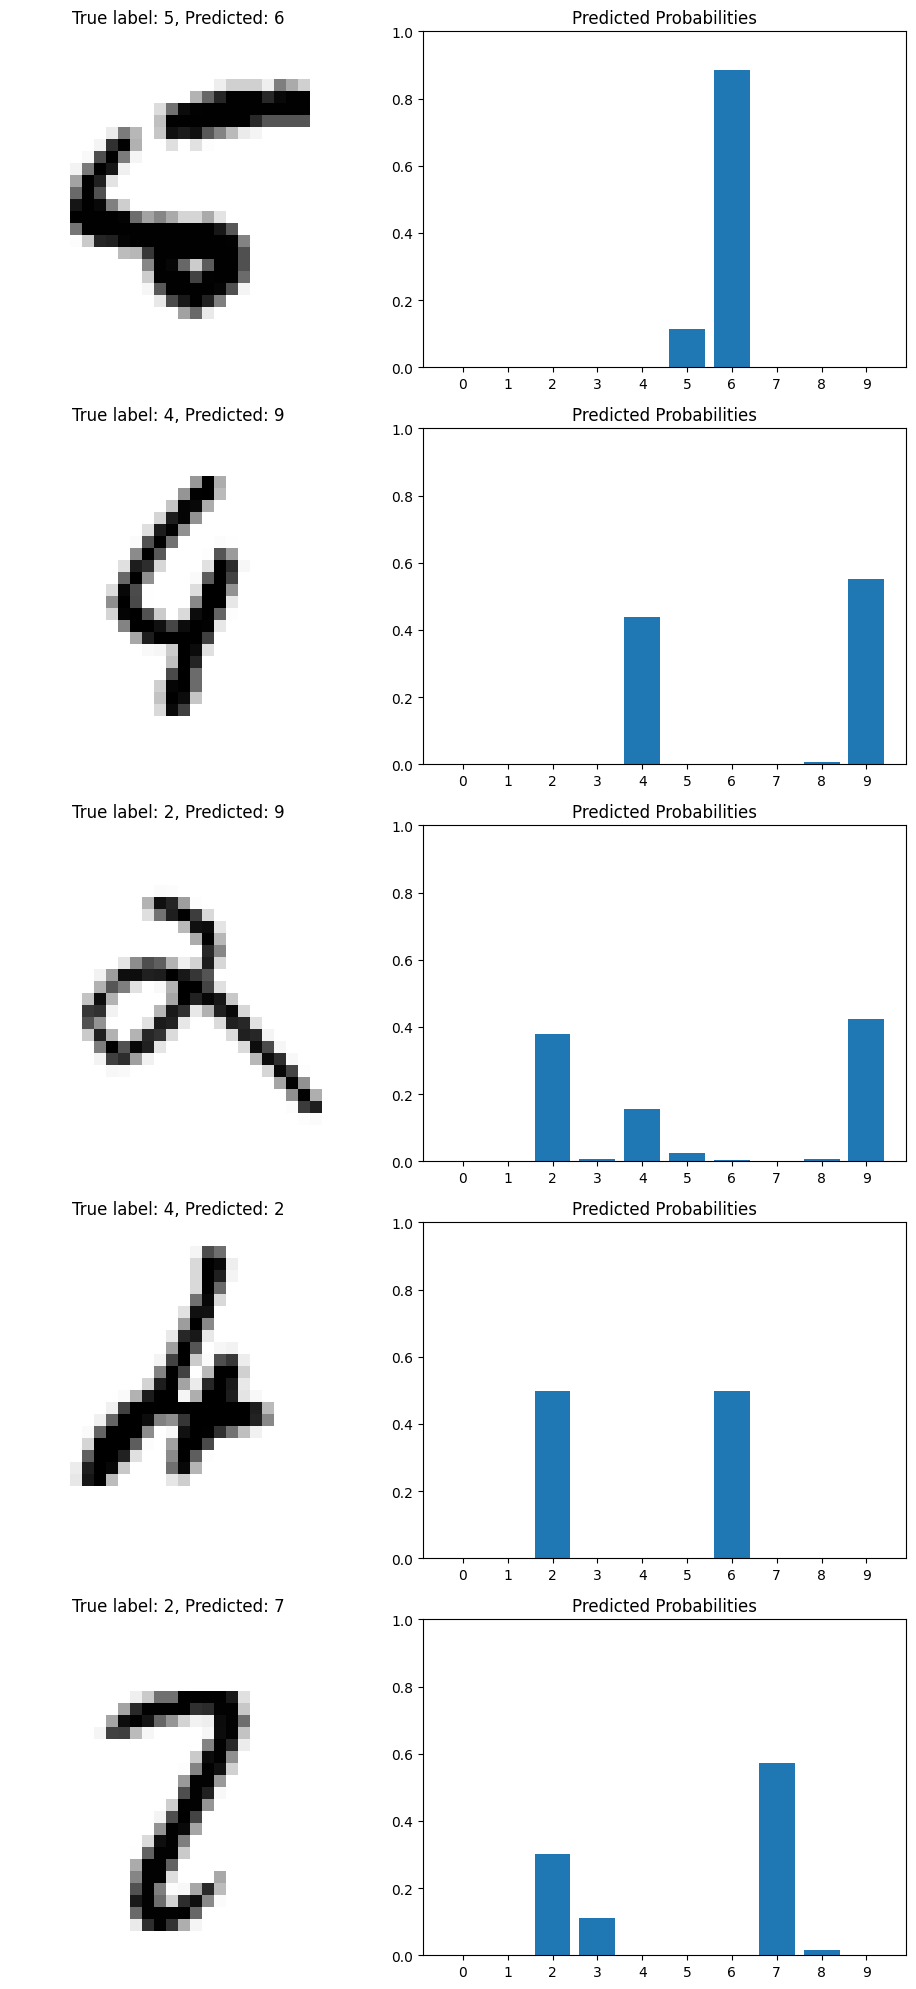

In [73]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred_nn_labels)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred_nn_labels)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred_nn_labels[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = y_test_pred_nn[idx,:]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

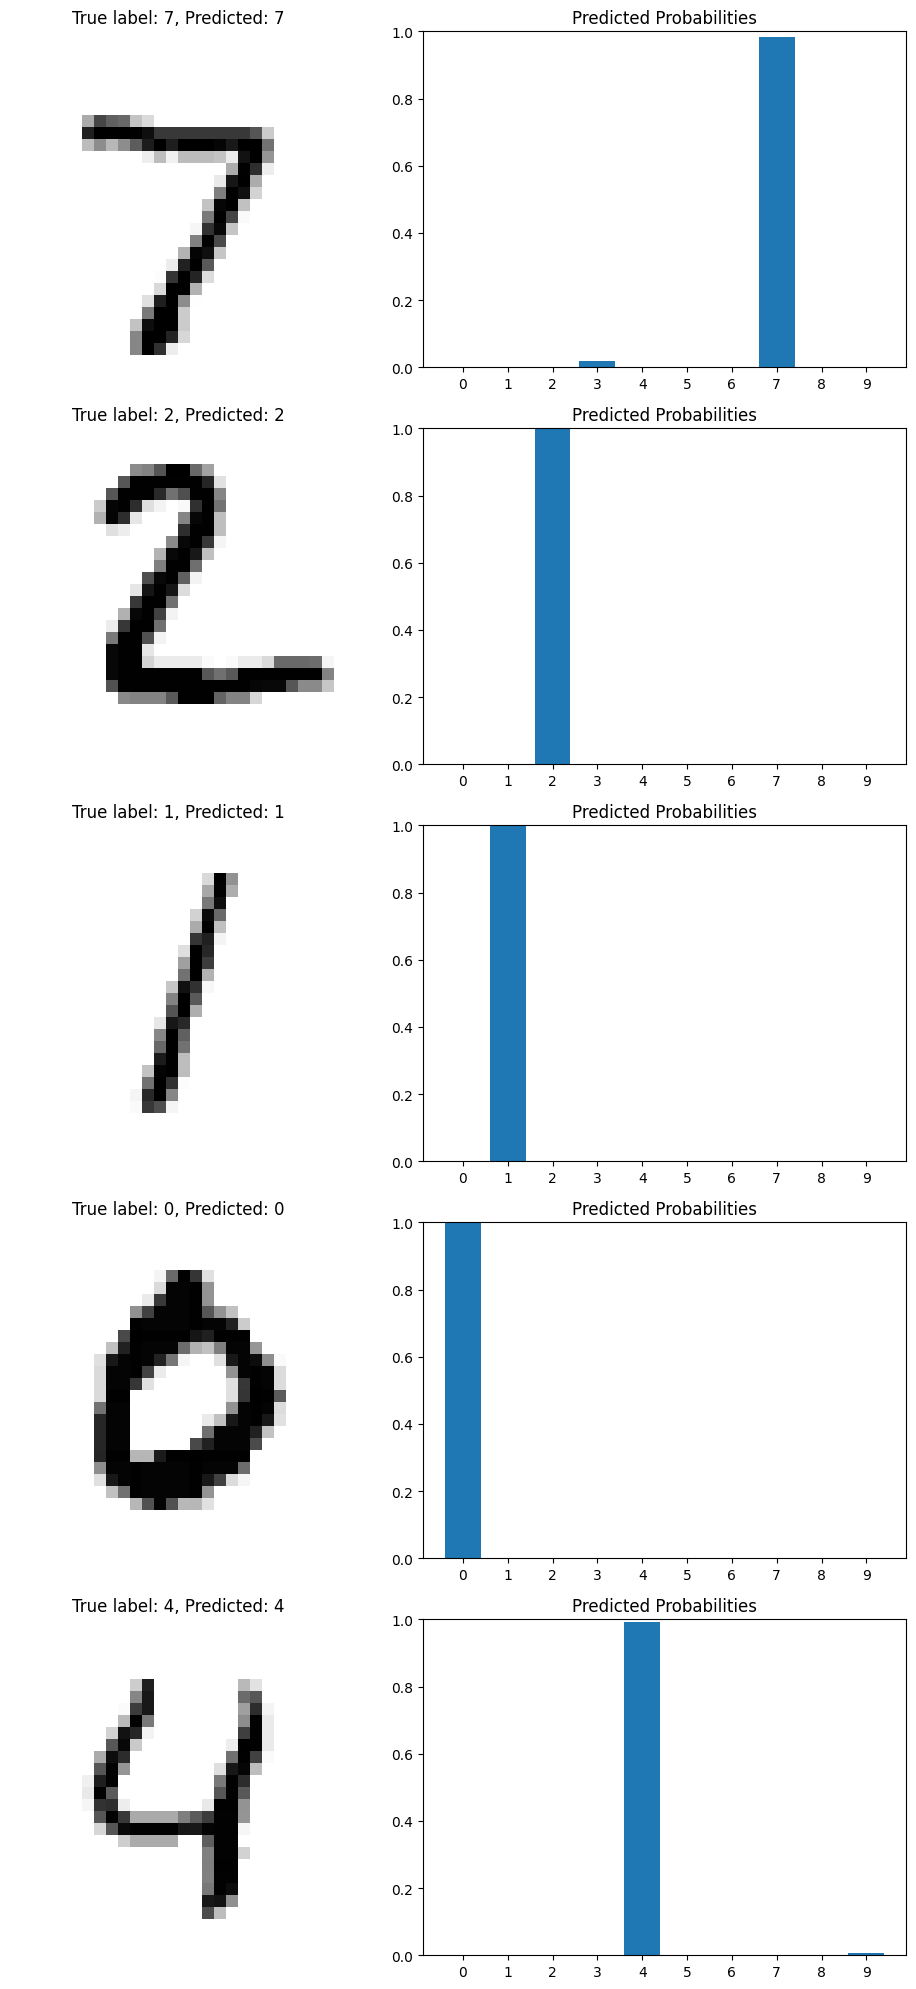

In [74]:

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred_nn_labels[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = y_test_pred_nn[idx,:]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

Cross entropy loss: 0.07799857757531052


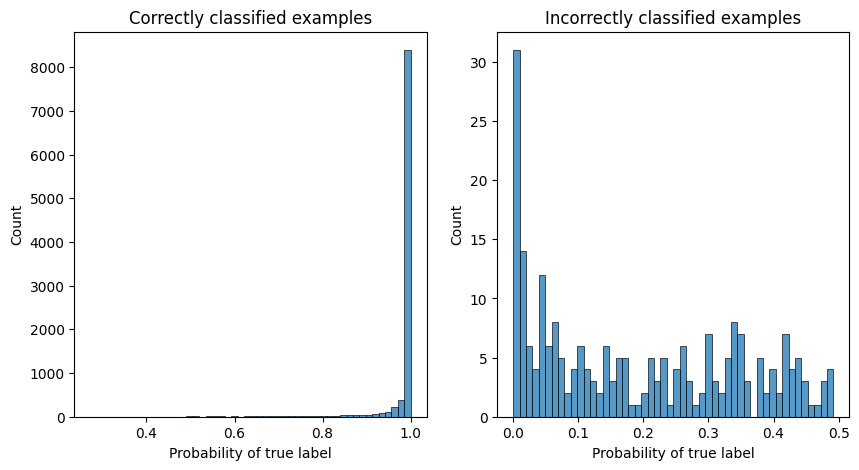

In [75]:
print('Cross entropy loss:', log_loss(y_test, y_test_pred_nn, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_nn[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

### 🚩 Exercise 10 (CORE)

Comment on the following:

a. Do you think you need to train the model for more epochs? 

b. Which model do you prefer: the baseline logisitic regression or the neural network? Consider the trade-off between: the number of parameters and predictive performance.

In [76]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

a. It does not seem that more epochs are needed, as the validation loss and accuracy are fairly flat. If we train for more epochs, we risk overfitting (indeed if you do, you will see that the validation loss and accuracy start to slightly increase).

b. The logistic regression model has 1,010 parameters, while the neural network has $784*128 +128 +10*128 + 10= 101,770$ parameters. That is a lot more parameters to learn. However, the neural network does provide significant improvements in accuracy, from 0.92 to 0.98, with improved performance across all classes in the classification report, and reduction in the cross entropy loss from 0.28 to 0.078. Also, when we look at some of the misclassified examples, the logisitic regression model misclassifies some examples who digits are visually evident. Indeed, looking at the histograms of the probabilities, we see that now over 8,000 images (previously 4,000) are correctly classified with high probability, while around 30 images (previously over 100) are incorrectly classified with high probability.

### 🚩 Exercise 11 (EXTRA)

Let's explore a deeper architecture.

- Build a deeper network with three hidden layers, with $D_1 = 128, D_2 = 64, D_1 = 32$ neurons and ReLU activation, and an output layer with 10 neurons and softmax activation.

- Compile and train the model with the same setting as the shallow model.

- Plot the loss and accuracy for the training and validation sets as a function of epochs. Do you think more epochs are needed?

- Plot the confusion matrix, print the classification report, and cross entropy loss. Visualize some the images, along with their probabilities for both correctly and incorrectly classified images.

- Which model do you prefer? Consider the trade-off between: the number of parameters and predictive performance.

In [77]:
# Define the model
model_deep = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# Compile the model
model_deep.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy'],
)

model_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8932 - loss: 0.3642 - val_accuracy: 0.9617 - val_loss: 0.1358
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9585 - loss: 0.1401 - val_accuracy: 0.9700 - val_loss: 0.1013
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9715 - loss: 0.0967 - val_accuracy: 0.9738 - val_loss: 0.0897
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9786 - loss: 0.0719 - val_accuracy: 0.9755 - val_loss: 0.0865
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0568 - val_accuracy: 0.9752 - val_loss: 0.0888
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9874 - loss: 0.0445 - val_accuracy: 0.9743 - val_loss: 0.0942
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9898 - loss: 0.0359 - val_accuracy: 0.9762 - val_loss: 0.0929
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0318 - val_accuracy: 0.

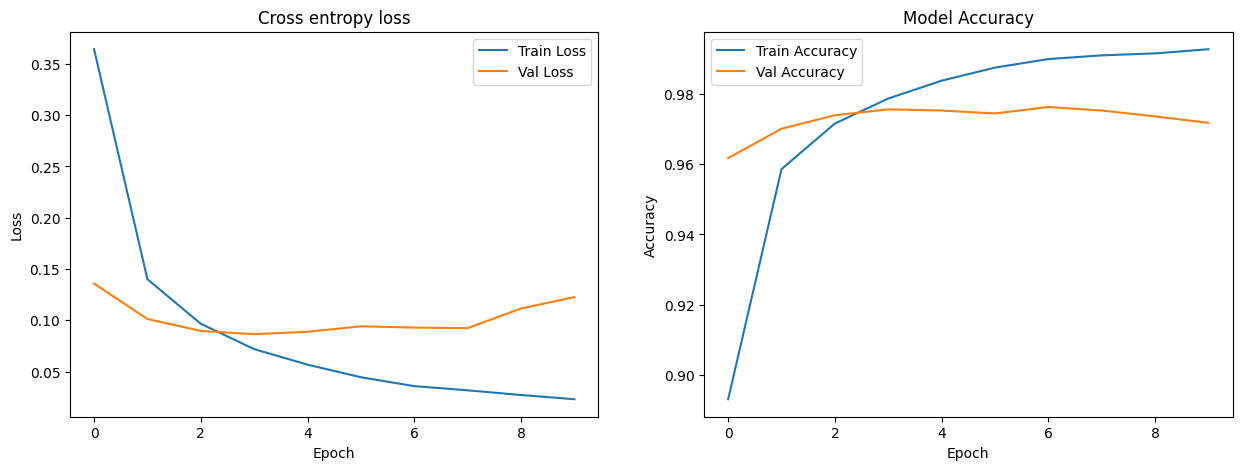

In [78]:
# Fit the model
model_deep.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.1)

# Plot the training history
history = model_deep.history.history
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.show()

No more epochs are needed for training the model. In fact, the validation loss seems to be slightly increasing after 2 epochs, so we may even want to train for less.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step


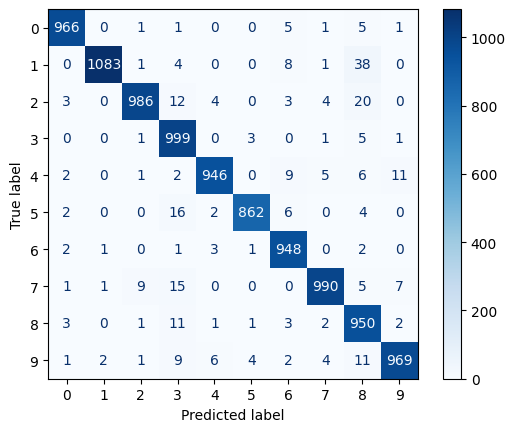

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.95      0.97      1135
           2       0.99      0.96      0.97      1032
           3       0.93      0.99      0.96      1010
           4       0.98      0.96      0.97       982
           5       0.99      0.97      0.98       892
           6       0.96      0.99      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.91      0.98      0.94       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [79]:
# Display the confusion matrix
y_test_pred_nn = model_deep.predict(X_test)
y_test_pred_nn_labels = np.argmax(y_test_pred_nn, axis=1)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_nn_labels, cmap='Blues')
plt.show()
print(classification_report(y_test, y_test_pred_nn_labels))

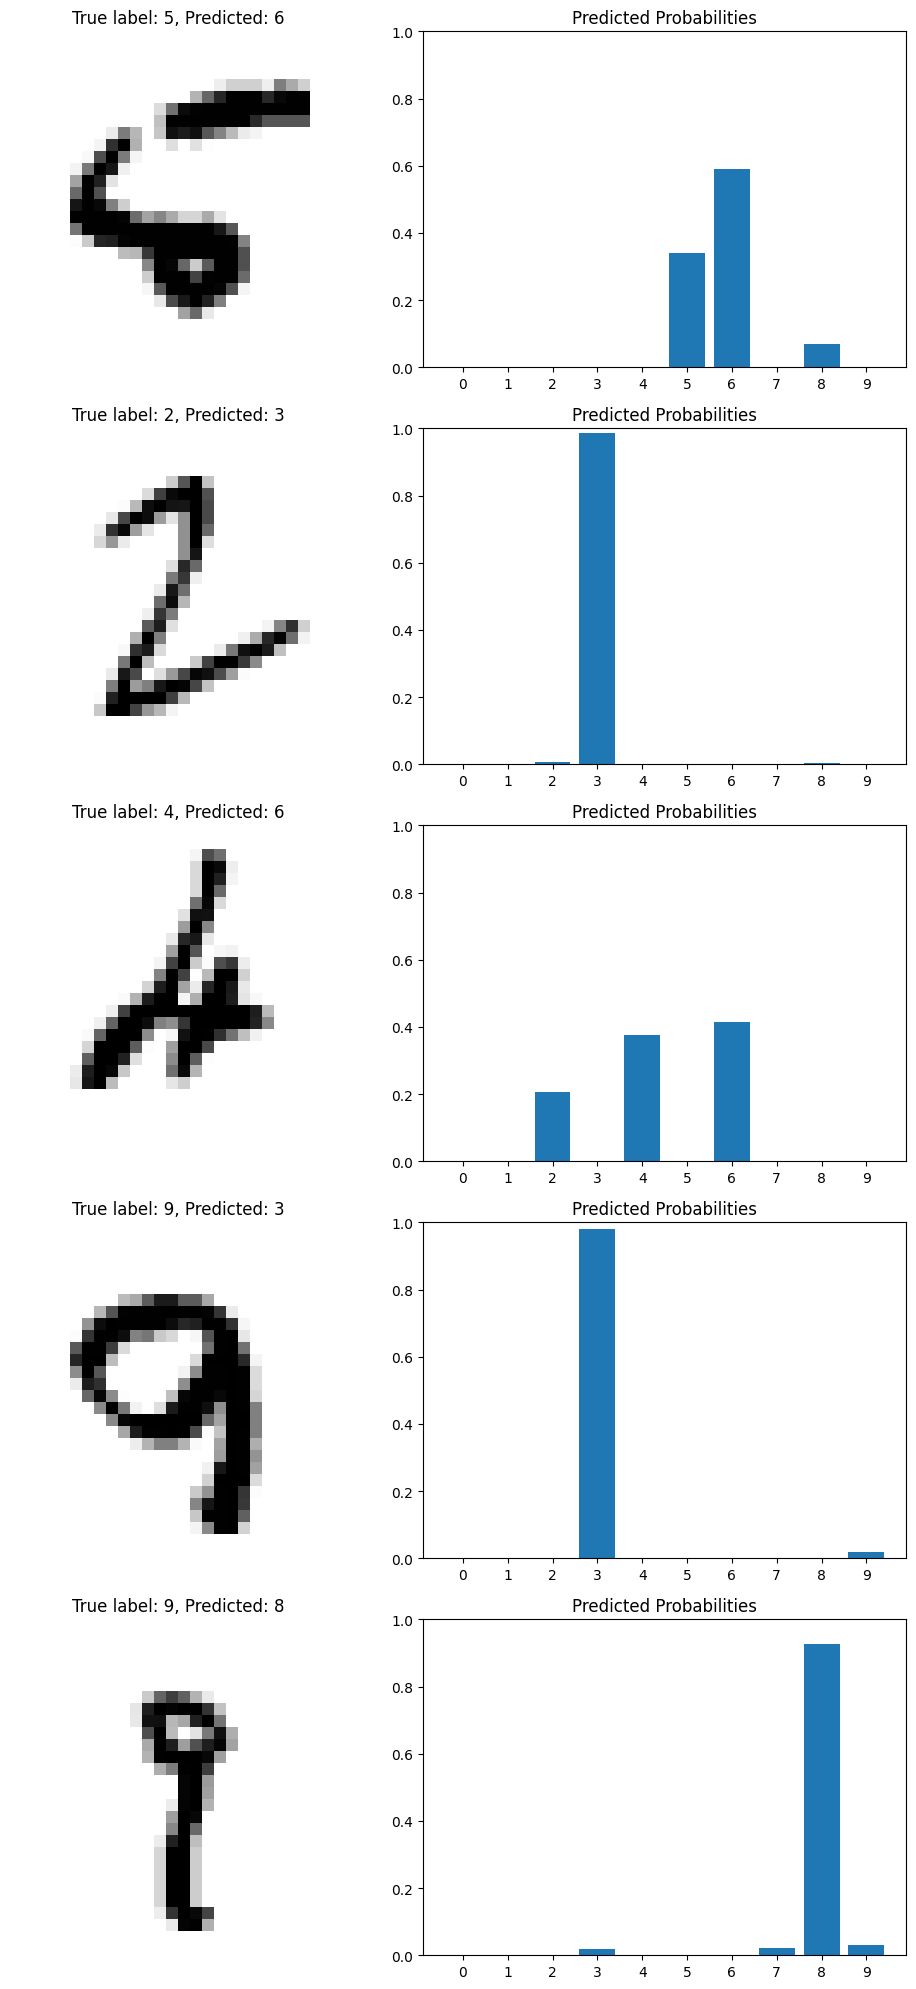

In [80]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred_nn_labels)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred_nn_labels)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred_nn_labels[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = y_test_pred_nn[idx,:]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

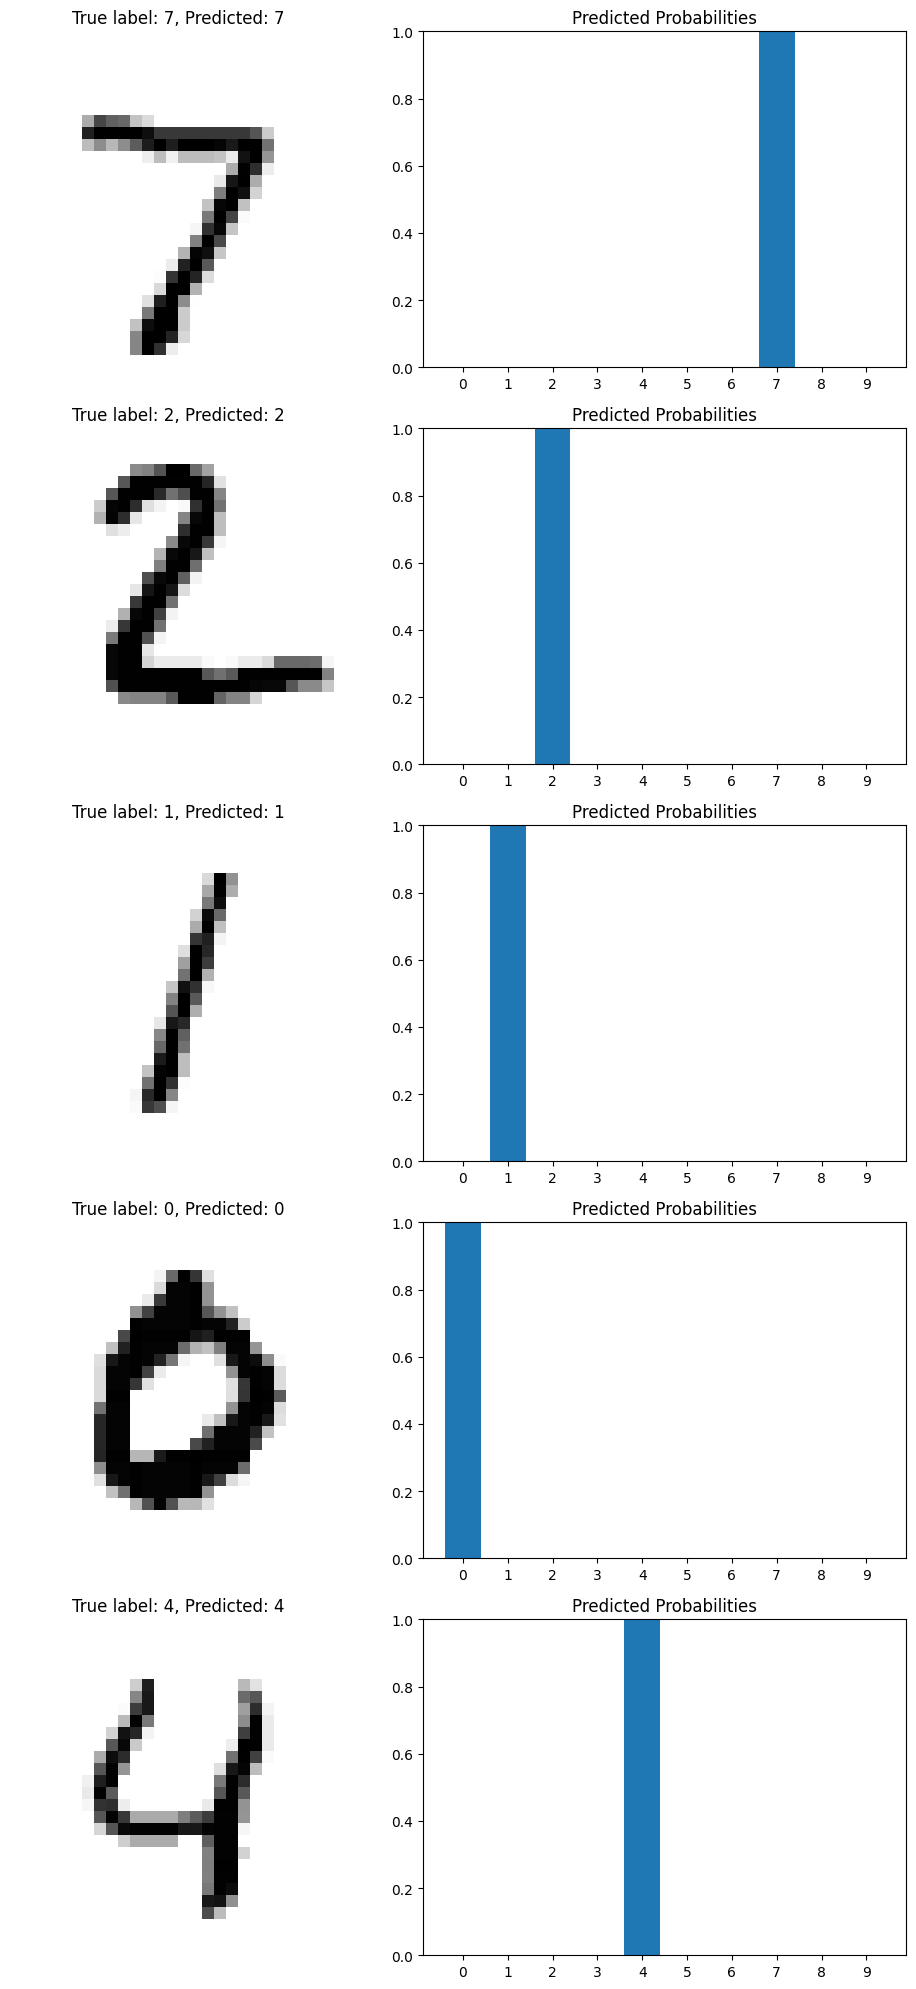

In [81]:
# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred_nn_labels[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = y_test_pred_nn[idx,:]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

Cross entropy loss: 0.11468263490179006


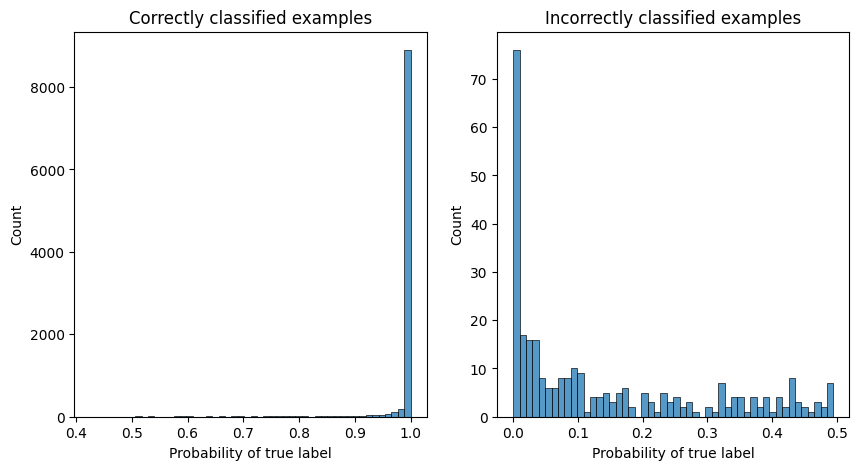

In [82]:
print('Cross entropy loss:', log_loss(y_test, y_test_pred_nn, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_nn[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

The deep model has 111,146 parameters, compared to the 101,770 parameters of the shallow model. In this case, the performance of the deep model is similar but slightly worse, with a slight reduction in accuracy, from 0.98 to 0.97, and slight increase in the cross entropy loss from 0.078 to 0.11. Given the increased complexity of the model, we prefer the simpler shallow model with less parameters and slightly improved predictive performance.

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
# !jupyter nbconvert --to pdf mlp_week09_key.ipynb 